In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.data.priority_labeler import (
    assign_priority_labels,
    validate_priority_labels,
    PRIORITY_COLUMN
)
from src.models.trainer import (
    build_logistic_regression,
    build_random_forest,
    build_linear_svc,
    train_model,
    save_model
)
from src.models.evaluator import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix,
    save_metrics_report,
    plot_model_comparison
)
from src.utils.config import (
    MODELS_DIR,
    PROCESSED_DATA_DIR,
    CATEGORY_TARGET,
    CATEGORY_TO_PRIORITY,
    PRIORITY_LABELS,
    TEXT_COLUMN
)

sns.set_theme(style="whitegrid")
print("Imports successful")

Imports successful


In [2]:
train_clean = pd.read_csv(PROCESSED_DATA_DIR / "train_cleaned.csv")
test_clean  = pd.read_csv(PROCESSED_DATA_DIR / "test_cleaned.csv")

# Assign rule-based priority labels
train_priority = assign_priority_labels(train_clean)
test_priority  = assign_priority_labels(test_clean)

print("=== TRAIN PRIORITY DISTRIBUTION ===")
print(train_priority[PRIORITY_COLUMN].value_counts())

print("\n=== TEST PRIORITY DISTRIBUTION ===")
print(test_priority[PRIORITY_COLUMN].value_counts())

print("\n=== VALIDATION ===")
validate_priority_labels(train_priority)
validate_priority_labels(test_priority)

[2026-04-11 11:21:50] INFO — src.data.priority_labeler — Assigning rule-based priority labels...
[2026-04-11 11:21:50] INFO — src.data.priority_labeler — Priority distribution:
[2026-04-11 11:21:50] INFO — src.data.priority_labeler —   High: 625
[2026-04-11 11:21:50] INFO — src.data.priority_labeler —   Critical: 546
[2026-04-11 11:21:50] INFO — src.data.priority_labeler —   Medium: 355
[2026-04-11 11:21:50] INFO — src.data.priority_labeler —   Low: 45
[2026-04-11 11:21:50] INFO — src.data.priority_labeler — Assigning rule-based priority labels...
[2026-04-11 11:21:50] INFO — src.data.priority_labeler — Priority distribution:
[2026-04-11 11:21:50] INFO — src.data.priority_labeler —   High: 270
[2026-04-11 11:21:50] INFO — src.data.priority_labeler —   Medium: 191
[2026-04-11 11:21:50] INFO — src.data.priority_labeler —   Critical: 138
[2026-04-11 11:21:50] INFO — src.data.priority_labeler —   Low: 58
=== TRAIN PRIORITY DISTRIBUTION ===
priority
High        625
Critical    546
Medium   

True

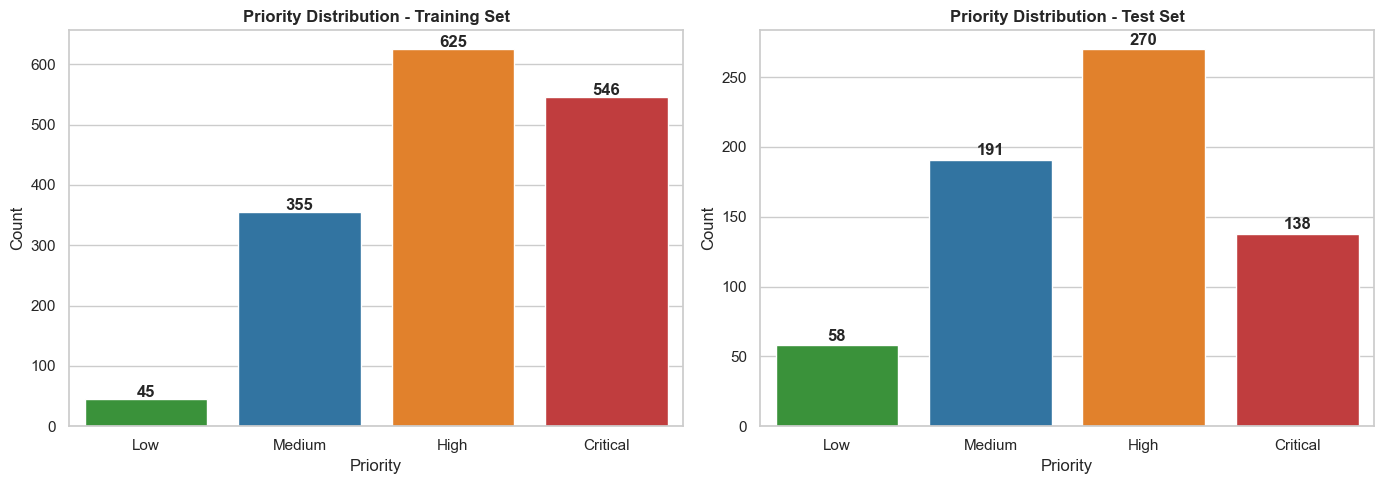

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

priority_order = ["Low", "Medium", "High", "Critical"]
colors = {
    "Low":      "#2ca02c",
    "Medium":   "#1f77b4",
    "High":     "#ff7f0e",
    "Critical": "#d62728"
}

for ax, (df, title) in zip(axes, [
    (train_priority, "Training Set"),
    (test_priority,  "Test Set")
]):
    counts = df[PRIORITY_COLUMN].value_counts().reindex(priority_order)
    palette = [colors[p] for p in priority_order]

    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=palette)
    ax.set_title(f"Priority Distribution - {title}", fontweight="bold")
    ax.set_xlabel("Priority")
    ax.set_ylabel("Count")

    for i, val in enumerate(counts.values):
        ax.text(i, val + 3, str(val), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/priority_distribution.png", dpi=150)
plt.show()

In [4]:
print("=== CATEGORY TO PRIORITY MAPPING ===\n")
print(f"{'Category':<25} {'Priority':<12} {'Train Count'}")
print("-" * 50)

for category, priority in CATEGORY_TO_PRIORITY.items():
    count = train_priority[
        train_priority[CATEGORY_TARGET] == category
    ].shape[0]
    print(f"{category:<25} {priority:<12} {count}")

=== CATEGORY TO PRIORITY MAPPING ===

Category                  Priority     Train Count
--------------------------------------------------
EOL                       Low          45
Computer-Services         Medium       65
O365                      Medium       127
Software                  Medium       163
Active Directory          High         84
Support general           High         541
Fileservice               Critical     546


In [5]:
splits = joblib.load(MODELS_DIR / "train_test_splits.pkl")

X_train_tfidf = splits["X_train_tfidf"]
X_test_tfidf  = splits["X_test_tfidf"]

# Get priority labels aligned to the same indices as our splits
y_pri_train = train_priority[PRIORITY_COLUMN].reset_index(drop=True)
y_pri_test  = test_priority[PRIORITY_COLUMN].reset_index(drop=True)

print(f"Training matrix: {X_train_tfidf.shape}")
print(f"Test matrix:     {X_test_tfidf.shape}")
print(f"\nTrain priority counts:")
print(y_pri_train.value_counts())

Training matrix: (1571, 1330)
Test matrix:     (657, 1330)

Train priority counts:
priority
High        625
Critical    546
Medium      355
Low          45
Name: count, dtype: int64


In [6]:
lr_model = build_logistic_regression()
lr_model = train_model(lr_model, X_train_tfidf, y_pri_train)

[2026-04-11 11:21:52] INFO — src.models.trainer — Training LogisticRegression...
[2026-04-11 11:21:53] INFO — src.models.trainer — LogisticRegression training complete


[2026-04-11 11:21:53] INFO — src.models.evaluator — Evaluating Logistic Regression...
[2026-04-11 11:21:53] INFO — src.models.evaluator —   Accuracy:  0.8219
[2026-04-11 11:21:53] INFO — src.models.evaluator —   Precision: 0.8452
[2026-04-11 11:21:53] INFO — src.models.evaluator —   Recall:    0.8219
[2026-04-11 11:21:53] INFO — src.models.evaluator —   F1 Score:  0.8262

=== CLASSIFICATION REPORT — Logistic Regression ===
              precision    recall  f1-score   support

    Critical       1.00      0.87      0.93       138
        High       0.87      0.73      0.80       270
         Low       1.00      1.00      1.00        58
      Medium       0.65      0.86      0.74       191

    accuracy                           0.82       657
   macro avg       0.88      0.87      0.87       657
weighted avg       0.85      0.82      0.83       657



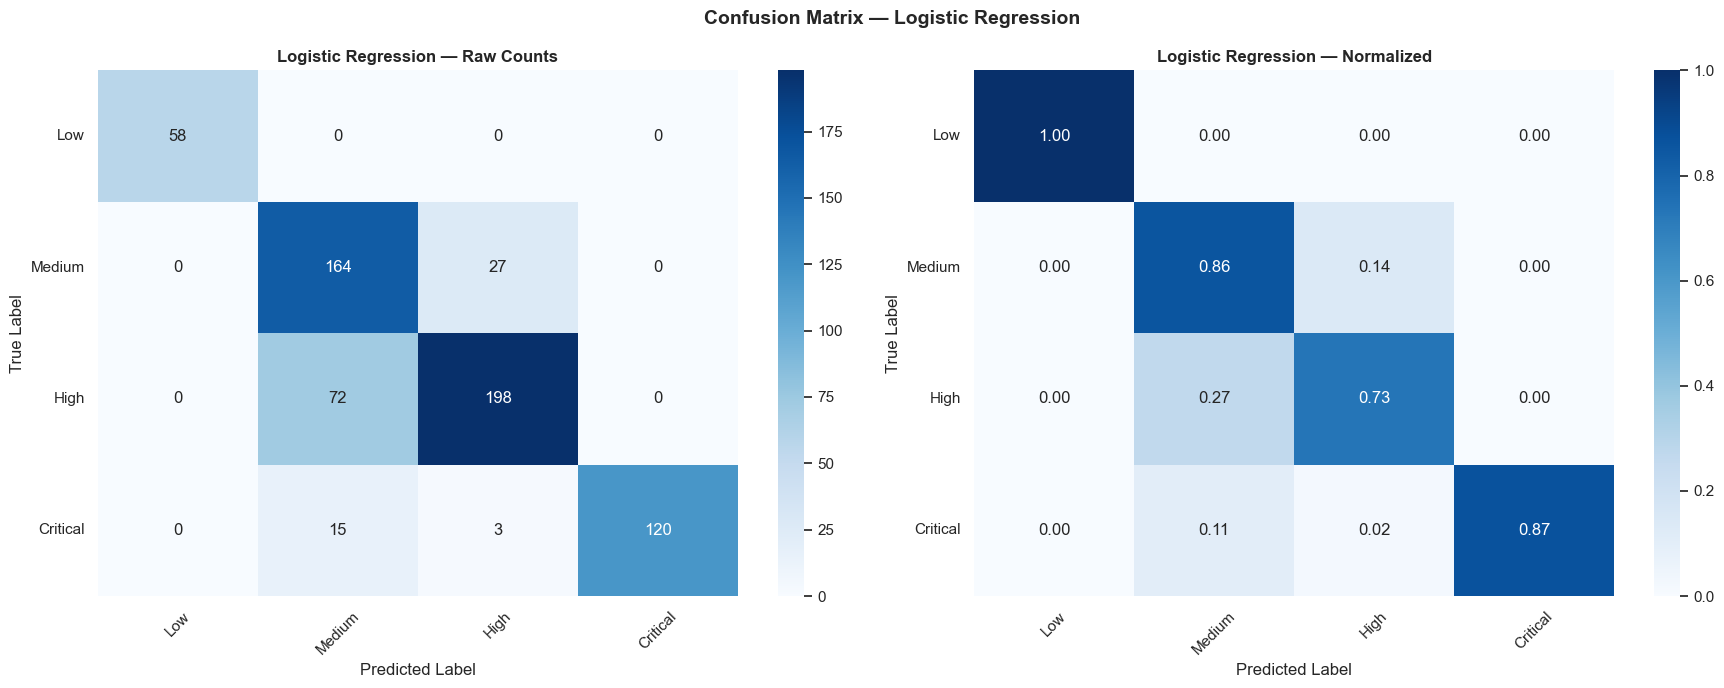

[2026-04-11 11:21:56] INFO — src.models.evaluator — Confusion matrix saved to E:\Future ml projects\FUTURE_ML_02\outputs\figures\priority_confusion_matrix_lr.png


In [7]:
lr_metrics, lr_preds = evaluate_model(
    lr_model, X_test_tfidf, y_pri_test, "Logistic Regression"
)

print_classification_report(y_pri_test, lr_preds, "Logistic Regression")

plot_confusion_matrix(
    y_pri_test, lr_preds,
    "Logistic Regression",
    PRIORITY_LABELS,
    "priority_confusion_matrix_lr.png"
)

In [8]:
rf_model = build_random_forest()
rf_model = train_model(rf_model, X_train_tfidf, y_pri_train)

[2026-04-11 11:21:56] INFO — src.models.trainer — Training RandomForestClassifier...
[2026-04-11 11:21:57] INFO — src.models.trainer — RandomForestClassifier training complete


[2026-04-11 11:21:57] INFO — src.models.evaluator — Evaluating Random Forest...
[2026-04-11 11:21:58] INFO — src.models.evaluator —   Accuracy:  0.8219
[2026-04-11 11:21:58] INFO — src.models.evaluator —   Precision: 0.8302
[2026-04-11 11:21:58] INFO — src.models.evaluator —   Recall:    0.8219
[2026-04-11 11:21:58] INFO — src.models.evaluator —   F1 Score:  0.8247

=== CLASSIFICATION REPORT — Random Forest ===
              precision    recall  f1-score   support

    Critical       0.98      0.87      0.92       138
        High       0.81      0.80      0.81       270
         Low       1.00      1.00      1.00        58
      Medium       0.69      0.77      0.73       191

    accuracy                           0.82       657
   macro avg       0.87      0.86      0.86       657
weighted avg       0.83      0.82      0.82       657



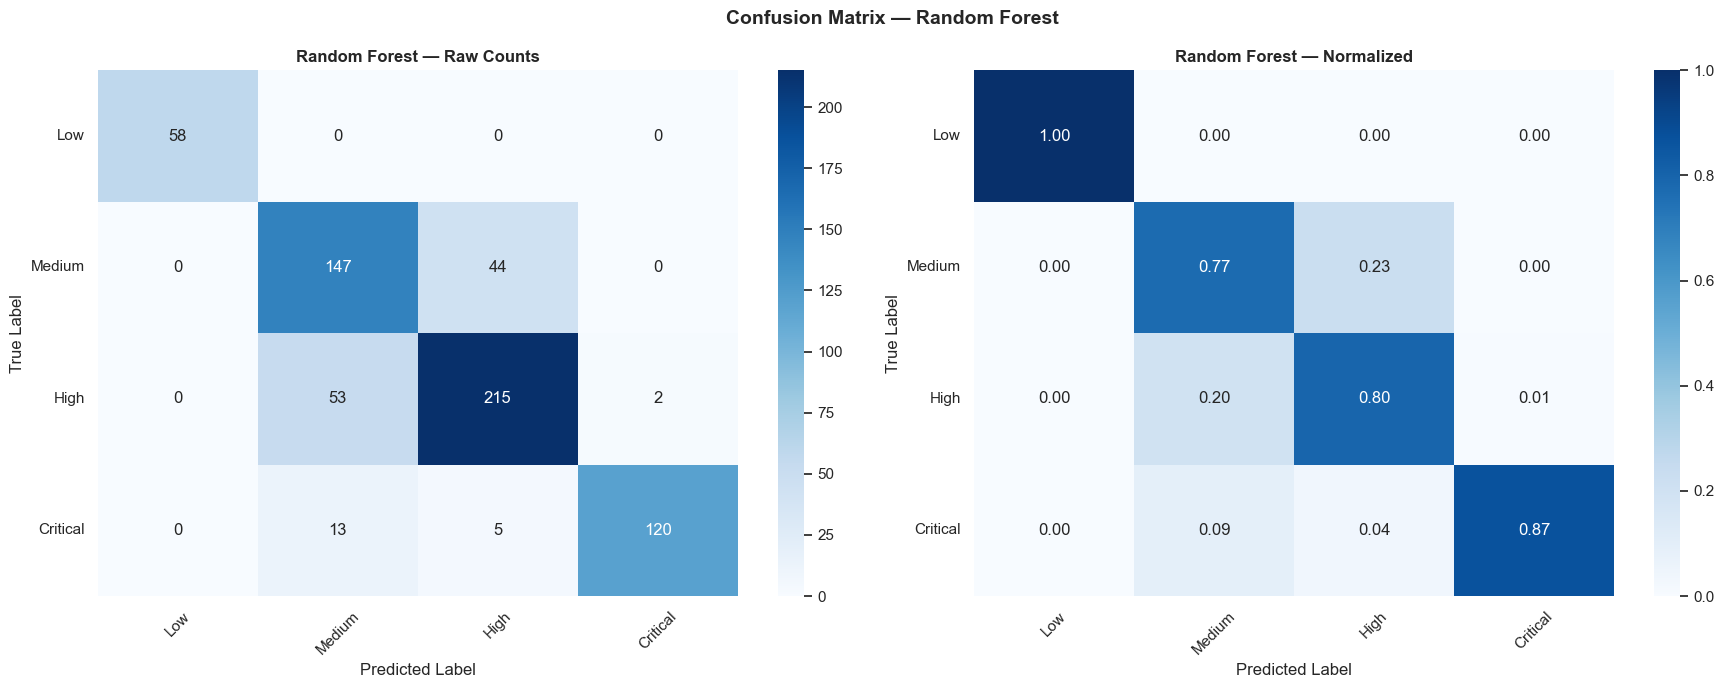

[2026-04-11 11:21:59] INFO — src.models.evaluator — Confusion matrix saved to E:\Future ml projects\FUTURE_ML_02\outputs\figures\priority_confusion_matrix_rf.png


In [9]:
rf_metrics, rf_preds = evaluate_model(
    rf_model, X_test_tfidf, y_pri_test, "Random Forest"
)

print_classification_report(y_pri_test, rf_preds, "Random Forest")

plot_confusion_matrix(
    y_pri_test, rf_preds,
    "Random Forest",
    PRIORITY_LABELS,
    "priority_confusion_matrix_rf.png"
)

In [10]:
svc_model = build_linear_svc()
svc_model = train_model(svc_model, X_train_tfidf, y_pri_train)

[2026-04-11 11:21:59] INFO — src.models.trainer — Training LinearSVC...
[2026-04-11 11:22:00] INFO — src.models.trainer — LinearSVC training complete


[2026-04-11 11:22:00] INFO — src.models.evaluator — Evaluating LinearSVC...
[2026-04-11 11:22:00] INFO — src.models.evaluator —   Accuracy:  0.8676
[2026-04-11 11:22:00] INFO — src.models.evaluator —   Precision: 0.8678
[2026-04-11 11:22:00] INFO — src.models.evaluator —   Recall:    0.8676
[2026-04-11 11:22:00] INFO — src.models.evaluator —   F1 Score:  0.8676

=== CLASSIFICATION REPORT — LinearSVC ===
              precision    recall  f1-score   support

    Critical       0.96      0.93      0.95       138
        High       0.84      0.87      0.86       270
         Low       1.00      1.00      1.00        58
      Medium       0.80      0.78      0.79       191

    accuracy                           0.87       657
   macro avg       0.90      0.90      0.90       657
weighted avg       0.87      0.87      0.87       657



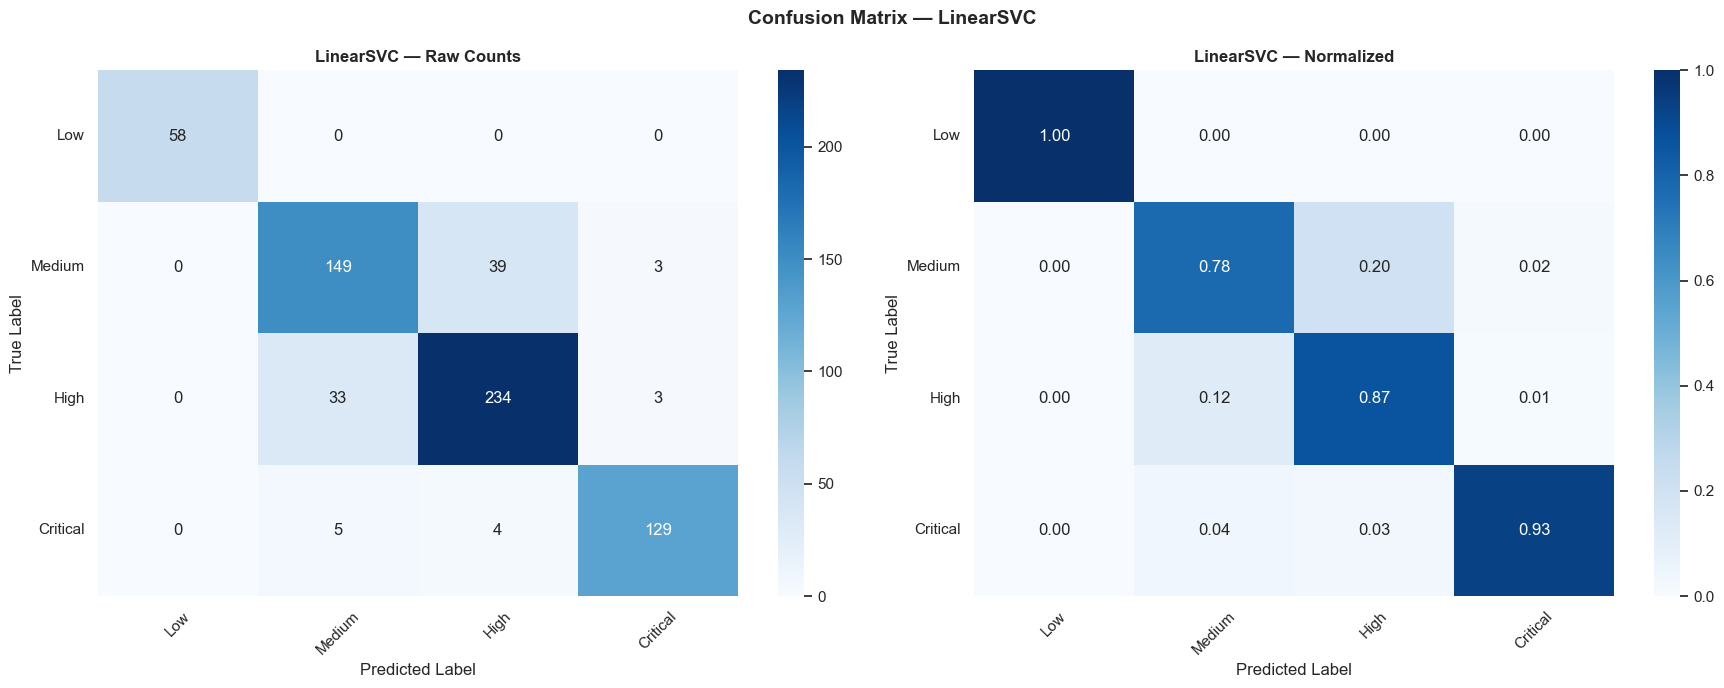

[2026-04-11 11:22:02] INFO — src.models.evaluator — Confusion matrix saved to E:\Future ml projects\FUTURE_ML_02\outputs\figures\priority_confusion_matrix_svc.png


In [11]:
svc_metrics, svc_preds = evaluate_model(
    svc_model, X_test_tfidf, y_pri_test, "LinearSVC"
)

print_classification_report(y_pri_test, svc_preds, "LinearSVC")

plot_confusion_matrix(
    y_pri_test, svc_preds,
    "LinearSVC",
    PRIORITY_LABELS,
    "priority_confusion_matrix_svc.png"
)

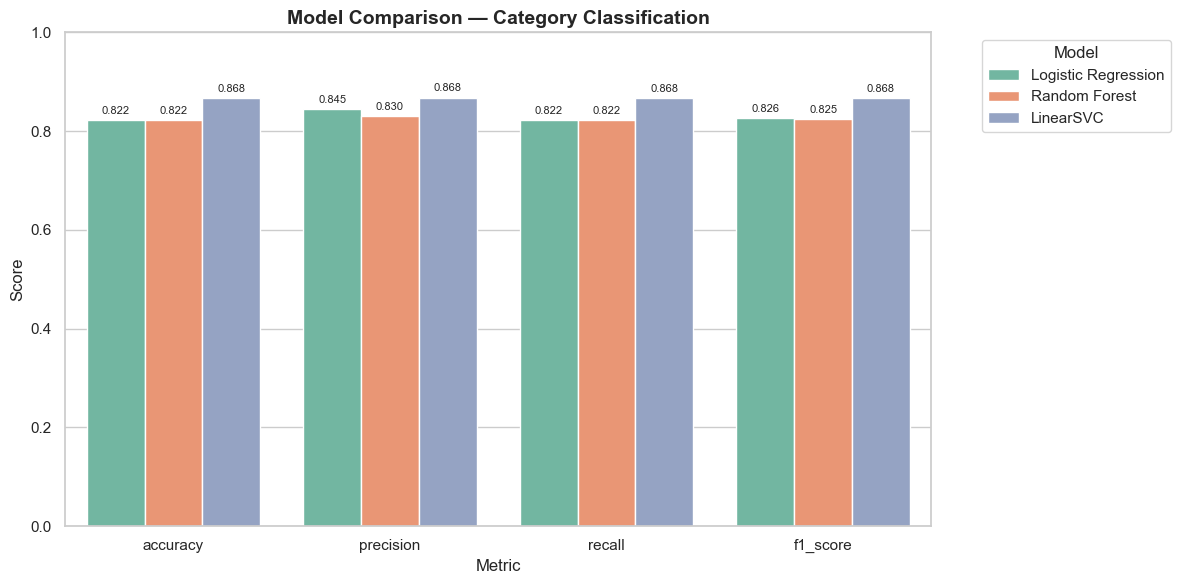

[2026-04-11 11:22:03] INFO — src.models.evaluator — Comparison chart saved to E:\Future ml projects\FUTURE_ML_02\outputs\figures\priority_model_comparison.png

=== FINAL COMPARISON TABLE ===
              model  accuracy  precision  recall  f1_score
          LinearSVC    0.8676     0.8678  0.8676    0.8676
Logistic Regression    0.8219     0.8452  0.8219    0.8262
      Random Forest    0.8219     0.8302  0.8219    0.8247


In [12]:
all_metrics = [lr_metrics, rf_metrics, svc_metrics]

plot_model_comparison(all_metrics, "priority_model_comparison.png")

print("\n=== FINAL COMPARISON TABLE ===")
df_results = pd.DataFrame(all_metrics)
df_results = df_results.sort_values("f1_score", ascending=False)
print(df_results.to_string(index=False))

In [13]:
best = max(all_metrics, key=lambda x: x["f1_score"])
print(f"Best model: {best['model']} with F1={best['f1_score']}")

model_map = {
    "Logistic Regression": lr_model,
    "Random Forest":       rf_model,
    "LinearSVC":           svc_model,
}

best_model = model_map[best["model"]]
save_model(best_model, "priority_classifier.pkl")
save_metrics_report(all_metrics, "priority_metrics.json")

print(f"\nBest priority model saved as priority_classifier.pkl")

Best model: LinearSVC with F1=0.8676
[2026-04-11 11:22:03] INFO — src.models.trainer — Model saved to E:\Future ml projects\FUTURE_ML_02\outputs\models\priority_classifier.pkl
[2026-04-11 11:22:03] INFO — src.models.evaluator — Metrics report saved to E:\Future ml projects\FUTURE_ML_02\outputs\reports\priority_metrics.json

Best priority model saved as priority_classifier.pkl


In [14]:
X_test_raw = splits["X_test"]

error_df = pd.DataFrame({
    "text":      X_test_raw.values,
    "true":      y_pri_test.values,
    "predicted": model_map[best["model"]].predict(X_test_tfidf)
})

errors = error_df[error_df["true"] != error_df["predicted"]]

print(f"Total errors: {len(errors)} out of {len(error_df)} ({len(errors)/len(error_df)*100:.1f}%)")

print(f"\n=== MOST COMMON PRIORITY CONFUSIONS ===")
confusion_pairs = errors.groupby(
    ["true", "predicted"]
).size().sort_values(ascending=False)
print(confusion_pairs.head(10))

print(f"\n=== SAMPLE MISCLASSIFIED TICKETS ===")
for _, row in errors.head(5).iterrows():
    print(f"\nTrue Priority:      {row['true']}")
    print(f"Predicted Priority: {row['predicted']}")
    print(f"Text:               {str(row['text'])[:200]}")

Total errors: 87 out of 657 (13.2%)

=== MOST COMMON PRIORITY CONFUSIONS ===
true      predicted
Medium    High         39
High      Medium       33
Critical  Medium        5
          High          4
High      Critical      3
Medium    Critical      3
dtype: int64

=== SAMPLE MISCLASSIFIED TICKETS ===

True Priority:      High
Predicted Priority: Medium
Text:               [TICKET ID] - New Support Ticket received  - Setup BB on mobile phone.

True Priority:      Medium
Predicted Priority: High
Text:               [TICKET ID] - New Support Ticket received  - Update Rstudio

True Priority:      High
Predicted Priority: Medium
Text:               [TICKET ID] - New Support Ticket received  - Reparos Telefone - A/C[LOCATION]FERRARI

True Priority:      High
Predicted Priority: Medium
Text:               reserva DHCPPoderia fazer uma reserva no DHCP? [LOCATION][MAC_ADDRESS]  é uma impressora.

True Priority:      Medium
Predicted Priority: High
Text:               [TICKET ID] - New Support

In [15]:
# Show what the full system produces for sample tickets
cat_model = joblib.load(MODELS_DIR / "category_classifier.pkl")
pri_model = best_model
vectorizer = joblib.load(MODELS_DIR / "tfidf_vectorizer.pkl")

sample_tickets = [
    "Cannot access shared folder on network drive",
    "Need to reset password for new employee account",
    "Outlook keeps crashing when opening attachments",
    "Request to decommission old server hardware",
    "Printer not connecting to workstation",
]

print("=== END TO END PREDICTIONS ===\n")
print(f"{'Ticket':<50} {'Category':<25} {'Priority'}")
print("-" * 90)

from src.data.preprocessor import clean_text

for ticket in sample_tickets:
    cleaned   = clean_text(ticket)
    features  = vectorizer.transform([cleaned])
    category  = cat_model.predict(features)[0]
    priority  = pri_model.predict(features)[0]
    print(f"{ticket:<50} {category:<25} {priority}")

=== END TO END PREDICTIONS ===

Ticket                                             Category                  Priority
------------------------------------------------------------------------------------------
Cannot access shared folder on network drive       Fileservice               Critical
Need to reset password for new employee account    Active Directory          High
Outlook keeps crashing when opening attachments    O365                      Medium
Request to decommission old server hardware        Support general           High
Printer not connecting to workstation              Computer-Services         Medium
